# UVA Foreign Giving Analysis

I'll compare UVA to appropriate peer institutions and the market overall. Then, I'll propose a strategy for finding new sources of foreign money and provide a quantitative analysis.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gifts = pd.read_csv("ForeignGifts_edu.csv")

gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [3]:
uva = gifts[gifts["Institution Name"] == "University of Virginia"].copy()
uva.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


### UVA Statistics Summary

In [4]:
uva.shape

(98, 10)

In [5]:
uva_total = uva["Foreign Gift Amount"].sum()
uva_count = uva["Foreign Gift Amount"].count()
uva_average = uva["Foreign Gift Amount"].mean()
uva_median = uva["Foreign Gift Amount"].median()

print(uva_total)
print(uva_count)
print(uva_average)
print(uva_median)

22189238
98
226420.79591836734
80535.5


UVA received approximately $22.2 million across 98 records. The average gift ($226,420.80) is substantially larger than the median ($80,535.50), indicating that some larger gifts pull the average upward.

### UVA Givings by Country
I will compare countries by the total amount, number, and average size of gifts received by UVA.

In [6]:
uva_country = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
    .agg(["sum", "count", "mean"])
    .sort_values("sum", ascending=False)
)

uva_country.head(10)

,sum,count,mean
Country of Giftor,,,
BANGLADESH,4228589,10,422858.900000
SWEDEN,4007552,10,400755.200000
TANZANIA,2776447,3,925482.333333
SWITZERLAND,2000000,2,1000000.000000
ENGLAND,1950666,31,62924.709677
GUERNSEY,1500000,3,500000.000000
FINLAND,1008384,7,144054.857143
BERMUDA,900000,1,900000.000000
KOREA,862787,6,143797.833333


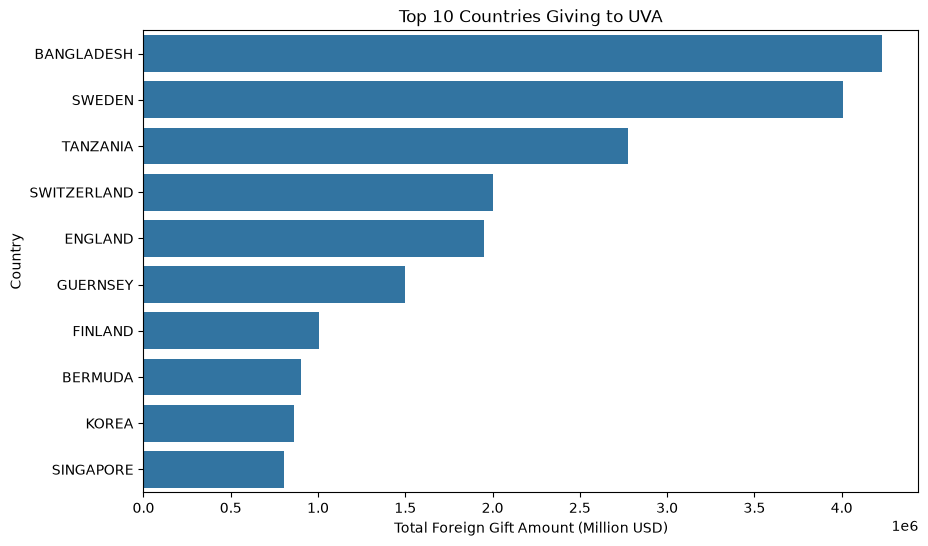

In [7]:
uva_country_plot = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=uva_country_plot,
    x="Foreign Gift Amount",
    y="Country of Giftor"
)

plt.title("Top 10 Countries Giving to UVA")
plt.xlabel("Total Foreign Gift Amount (Million USD)")
plt.ylabel("Country")

plt.show()

Bangladesh and Sweden are UVA's largest sources by total amount. England contributes more frequently than either of them, showing that gift frequency and total gift value do not necessarily identify the same countries.

# Comparing UVA to Peer Institutions

I'll compare UVA to several other major public research universities represented in the dataset.

In [8]:
peer_institutions = [
    "University of Virginia",
    "University of North Carolina - Chapel Hill",
    "University of Michigan - Ann Arbor",
    "University of California, Berkeley",
    "University of California, Los Angeles",
    "University of Texas at Austin"
]

peer_data = gifts[gifts["Institution Name"].isin(peer_institutions)]

peer_summary = (
    peer_data.groupby("Institution Name")["Foreign Gift Amount"]
    .agg(["sum", "count", "mean", "median"])
    .sort_values("sum", ascending=False)
)

peer_summary

,sum,count,mean,median
Institution Name,,,,
"University of California, Berkeley",294479904,394,747410.923858,424025.0
University of Michigan - Ann Arbor,287336783,715,401869.626573,200000.0
"University of California, Los Angeles",242146363,3916,61835.128447,250.0
University of Texas at Austin,85858408,377,227741.135279,97911.0
University of North Carolina - Chapel Hill,41292544,286,144379.524476,33548.0
University of Virginia,22189238,98,226420.795918,80535.5


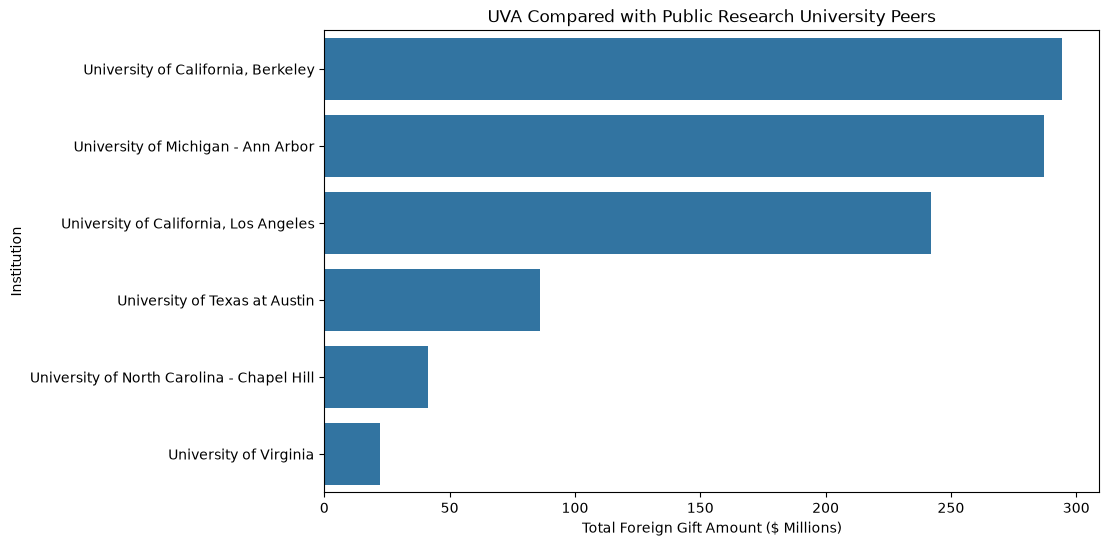

In [9]:
peer_plot = (
    peer_data.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

peer_plot["Total Millions"] = peer_plot["Foreign Gift Amount"] / 1000000
plt.figure(figsize=(10, 6))

sns.barplot(
    data=peer_plot,
    x="Total Millions",
    y="Institution Name"
)

plt.title("UVA Compared with Public Research University Peers")
plt.xlabel("Total Foreign Gift Amount ($ Millions)")
plt.ylabel("Institution")
plt.show()

In [18]:
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'

# Filter to only US peer institutions
df_filtered = df[df[recipi].isin(peer_institutions)]

flows = (
    df_filtered.groupby([recipi,  # Institutions on left
                giftor])  # Countries on right
      [flow]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

labels = (
    flows[recipi].tolist()
    + flows[giftor].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(
            label=labels,
            pad=15,
            thickness=20
        ),
        link=dict(
            source=flows[recipi].map(labels.index),
            target=flows[giftor].map(labels.index),
            value=flows[flow],
            color='rgba(200, 200, 200, 0.3)'  # Light gray with transparency
        )
    )
)

fig.update_layout(
    title="Foreign Gift Flows: US Peer Institutions to Countries",
    font=dict(size=11),
    height=700,
    width=1200,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.show()

UVA has the lowest total foreign funding among the selected similar universities. This indicates a substantial gap between UVA and several comparable public research universities in the dataset.

# Comparing UVA to the Overall Market

I will now compare UVA with all institutions in the dataset.

In [11]:
institution_totals = (
    gifts.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
)

institution_counts = (
    gifts.groupby("Institution Name")["Foreign Gift Amount"]
    .count()
    .sort_values(ascending=False)
)

uva_total_rank = institution_totals.index.get_loc("University of Virginia") + 1
uva_count_rank = institution_counts.index.get_loc("University of Virginia") + 1

print(f"Number of institutions: {len(institution_totals)}")
print(f"UVA rank by total amount: {uva_total_rank}")
print(f"UVA rank by gift count: {uva_count_rank}")
print(f"Average institution total: ${institution_totals.mean():,.2f}")
print(f"Median institution total: ${institution_totals.median():,.2f}")
print(f"UVA total: ${uva_total:,.2f}")

Number of institutions: 318
UVA rank by total amount: 101
UVA rank by gift count: 57
Average institution total: $52,202,878.97
Median institution total: $6,486,791.50
UVA total: $22,189,238.00


# Identifying Potential New Foreign Markets

One way you could find potential new sources of foreign aid is to identify countries that provide substantial funding to the overall market and to UVA's peer universities but currently provide much less or no funding to UVA.

In [12]:
peer_only = peer_data[
    peer_data["Institution Name"] != "University of Virginia"
]

market_country_total = (
    gifts.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
)

peer_country_total = (
    peer_only.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
)

uva_country_total = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
)

country_opportunity = pd.DataFrame({
    "Market Total": market_country_total,
    "Peer Total": peer_country_total,
    "UVA Total": uva_country_total
}).fillna(0)

new_country_opportunities = (
    country_opportunity[
        country_opportunity["UVA Total"] == 0
    ]
    .sort_values("Peer Total", ascending=False)
)

new_country_opportunities.head(10)

,Market Total,Peer Total,UVA Total
Country of Giftor,,,
CHINA,1237952112,93581720.0,0.0
GERMANY,442475605,56589333.0,0.0
CANADA,898160656,51360205.0,0.0
HONG KONG,887402529,51229248.0,0.0
SAUDI ARABIA,1065205930,50053336.0,0.0
TAIWAN,110412151,23695815.0,0.0
DENMARK,173956102,23163816.0,0.0
PHILIPPINES,19328737,16325267.0,0.0
IRELAND,109214628,12945299.0,0.0


China is the strongest potential new market based on this comparison, followed by Germany, Canada, Hong Kong, and Saudi Arabia. Each provides substantial funding to UVA's selected peers while having no reported UVA funding in the dataset. UVA could also continue developing existing relationships in countries such as Bangladesh and Sweden.